Notebook to run mean_dist, then join kuhn greenness (HLakes) to liu greenness (GLAKES), then to GLOBATHY
Calculating mean dist takes 36 hrs

Prerequisite: fix HL geoms,.

In [25]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadKuhnGreenness, loadGreenness, loadLiu, loadGlobathy, GLAKES_filtered_fix_aqveg_dist_pth, greennessx2_pth
from land_cover.distance import calcMeanBoundDist

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
## I/O
liu_mean_dist_out_pth = GLAKES_filtered_fix_aqveg_dist_pth

In [3]:
gdf_liu = loadLiu()

In [4]:
# TEMP: crop down gdf
# gdf_liu = gdf_liu[100000:100100].reset_index(drop=True)

In [5]:
gdf_liu

,OBJECTID,Lake_id,Area_bound,Area_PW,Continent,Lat,Lon,GFed_flag,PFed_flag,Endo_flag,...,NDVI1121,area_1984_,area_2000_,area_2010_,LEV_p1,LEV_p2,LEV_p3,LEV_p13ain,LEV_p13rin,geometry
0,3.0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,...,0.68,80903.091562,81679.557074,81192.035002,0.008512,0.007922,0.007740,-0.601649,-0.000771,"POLYGON ((-92.00626 46.68239, -92.00653 46.682..."
1,8.0,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,...,0.58,30156.030260,30565.860504,30502.390581,0.001103,0.002080,0.003208,0.645770,0.002105,"POLYGON ((-119.5765 66.99075, -119.5765 66.990..."
2,10.0,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,...,NaN,26977.563484,27182.922134,27256.549512,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-96.8945 55.40917, -96.89435 55.4091..."
3,11.0,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,...,0.70,26559.357871,26710.565325,26650.593451,0.048299,0.055355,0.090343,11.249214,0.042045,"POLYGON ((-111.128 62.3325, -111.12775 62.3325..."
4,16.0,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,...,0.72,17171.066362,17284.003108,17304.408409,0.113397,0.086365,0.090666,-3.782168,-0.022730,"POLYGON ((29.8255 61.20653, 29.82523 61.20653,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878279,3426379.0,3426379,0.030000,0.023372,North America,55.945998,-73.388277,0,1,0,...,NaN,0.023690,0.024181,0.025631,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-73.38675 55.9465, -73.38675 55.9452..."
1878280,3426383.0,3426383,0.030000,0.021656,North America,47.218059,-79.545936,0,0,0,...,NaN,0.024424,0.025390,0.026250,90.102849,0.000000,20.958554,-0.016505,-69.144295,"POLYGON ((-79.5445 47.219, -79.5445 47.21825, ..."
1878281,3426386.0,3426386,0.030000,0.025493,North America,57.038875,-66.618051,0,1,0,...,NaN,0.025496,0.026948,0.027198,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-66.618 57.04, -66.618 57.03975, -66..."
1878282,3426387.0,3426387,0.030000,0.021101,North America,63.005278,-147.988122,0,1,0,...,NaN,0.026927,0.022759,0.025122,0.000000,0.000000,29.270871,0.007353,29.270871,"POLYGON ((-147.9855 63.0055, -147.9855 63.0047..."


Calc mean_dist in parallel  

In [6]:
# typical vertex numbers: some have ~100, others rarely 100k
# Handle both Polygon and MultiPolygon geometries
num_vertices = []
for geom in gdf_liu.iloc[:100].geometry:
    if geom.geom_type == 'Polygon':
        num_vertices.append(len(geom.exterior.coords))
    elif geom.geom_type == 'MultiPolygon':
        # Sum vertices from all polygons in the MultiPolygon
        total = sum(len(poly.exterior.coords) for poly in geom.geoms)
        num_vertices.append(total)
    else:
        num_vertices.append(None)
print(num_vertices)

[91897, 95109, 224227, 107883, 52035, 42053, 168712, 55576, 100284, 39267, 64126, 36155, 27315, 122649, 189579, 35821, 16149, 91339, 49236, 127620, 37823, 14655, 31140, 59905, 56963, 33198, 11929, 52619, 50008, 35108, 14761, 33923, 59060, 48305, 28609, 16855, 43743, 22458, 18001, 21706, 17501, 20234, 73632, 15791, 46951, 7277, 6987, 22073, 4293, 15117, 37595, 63213, 26787, 30954, 17129, 46655, 31840, 33590, 30183, 26626, 48628, 31214, 19864, 26170, 20989, 8817, 23951, 31607, 12889, 38637, 14009, 36424, 29464, 11942, 28359, 14447, 19319, 23501, 8045, 48274, 37753, 27153, 16597, 22350, 9145, 26275, 23743, 7029, 5329, 10682, 30275, 18941, 30333, 10489, 21741, 24692, 5745, 21885, 8527, 10339]


In [7]:
# reproj to equal-area, temporarily

"""
Equal-area projection for maps showing a hemisphere

Lambert azimuthal equal-area projection PROJ WKT

Center latitude: 65.49º N

Center longitude: 2.11º E
"""
geom = gdf_liu.geometry
crs = gdf_liu.crs
gdf_liu = gdf_liu.to_crs("+proj=laea +lon_0=-37 +lat_0=65.49 +datum=WGS84 +units=m +no_defs")

ETA 36 hrs for 1.1 M features at (num_samples=10000, simplify=200, simplify_vertex_threshold=40000) \
ETA < 40 hrs for 1.9 M features at (num_samples=5000, simplify=200, simplify_vertex_threshold=40000)

In [9]:
print("Calc...")
gdf_liu = calcMeanBoundDist(
    gdf_liu, include_max=True, num_samples=5000, simplify=200, simplify_vertex_threshold=40000
)

Calc...
[########################################] | 100% Completed | 37hr 14m


Save

In [10]:
# un-reproject
gdf_liu["geometry"] = geom
gdf_liu.crs = crs

In [ ]:
# gdf_liu.to_file(
#     "/Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_filtered_fix_aqveg_dist.gpkg"
# )

In [11]:
gdf_liu.to_file(liu_mean_dist_out_pth)

/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_36927/1818012403.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_liu.to_file(liu_mean_dist_out_pth)
/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'mean_bound_dist' to 'mean_bound'
  ogr_write(
/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'max_bound_dist' to 'max_bound_'
  ogr_write(
/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value -56148430.0239839852 of field LEV_p13rin of feature 45588 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: 2GB file size limit reach

In [18]:
print(f"Wrote to file: {liu_mean_dist_out_pth}")

Wrote to file: /Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_filtered_fix_aqveg_dist.shp


Join to Kuhn

In [ ]:
# Load, if skipping
# gdf_liu = gpd.read_file(liu_mean_dist_out_pth)

In [12]:
gdf_kuhn = loadKuhnGreenness()

In [13]:
gdf_kuhn

,Hylak_id,Lake_name,Country,Continent,Poly_src,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,...,geometry,continent,country,latitude,longitude,sen_slope,mann_kendall_trend,trend_significance,b2_mean,b2_stddev
0,2,Great Bear,Canada,North America,CanVec,1,0,30450.64,5331.72,8.62,...,"POLYGON ((-119.78782 67.03574, -119.78637 67.0...",North America,Canada,65.999359,-120.967234,-0.000011,no sig. trend,0.95,0.0247,0.0032
1,3,Great Slave,Canada,North America,CanVec,1,0,26734.29,9814.16,16.93,...,"POLYGON ((-109.93976 62.95851, -109.93831 62.9...",North America,Canada,61.784589,-113.742931,-0.000300,no sig. trend,0.38,0.0595,0.0020
2,24,Aberdeen,Canada,North America,CanVec,1,0,1102.61,839.04,7.13,...,"POLYGON ((-97.92986 64.7425, -97.93104 64.7418...",North America,Canada,64.537914,-98.828092,0.000164,no sig. trend,0.73,0.0478,0.0069
3,25,Baker,Canada,North America,CanVec,1,0,1664.70,896.50,6.20,...,"POLYGON ((-96.04089 64.32023, -96.0355 64.3185...",North America,Canada,64.158695,-95.266193,-0.000469,no sig. trend,0.28,0.0457,0.0043
4,26,Dubawnt,Canada,North America,CanVec,1,0,3583.21,2557.78,12.05,...,"POLYGON ((-100.77464 63.59319, -100.77359 63.5...",North America,Canada,63.111650,-101.408577,-0.000279,no sig. trend,0.27,0.0344,0.0045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472884,968860,None,Canada,North America,CanVec,1,0,0.39,3.43,1.55,...,"POLYGON ((-95.41912 49.74055, -95.41877 49.740...",North America,Canada,49.737835,-95.418506,-0.000106,no sig. trend,0.31,0.0221,0.0016
472885,969007,None,Canada,North America,CanVec,1,0,0.34,3.33,1.61,...,"POLYGON ((-95.40814 49.73289, -95.40865 49.732...",North America,Canada,49.729990,-95.413438,-0.000090,no sig. trend,0.63,0.0213,0.0029
472886,969097,None,Canada,North America,CanVec,1,0,0.17,1.57,1.09,...,"POLYGON ((-95.4637 49.72635, -95.46122 49.7257...",North America,Canada,49.724075,-95.462516,-0.000172,no sig. trend,0.16,0.0211,0.0016
472887,969223,None,Canada,North America,CanVec,1,0,0.13,2.08,1.60,...,"POLYGON ((-96.26204 49.71645, -96.26198 49.716...",North America,Canada,49.715035,-96.259026,-0.002190,no sig. trend,0.06,0.0849,0.0024


In [44]:
gdf_kuhn.columns

Index(['Hylak_id', 'Lake_name', 'Country', 'Continent', 'Poly_src',
       'Lake_type', 'Grand_id', 'Lake_area', 'Shore_len', 'Shore_dev',
       'Vol_total', 'Vol_res', 'Vol_src', 'Depth_avg', 'Dis_avg', 'Res_time',
       'Elevation', 'Slope_100', 'Wshd_area', 'Pour_long', 'Pour_lat',
       'geometry', 'continent', 'country', 'latitude', 'longitude',
       'sen_slope', 'mann_kendall_trend', 'trend_significance', 'b2_mean',
       'b2_stddev'],
      dtype='object')

In [45]:
gdf_sjoin = gdf_liu.sjoin(gdf_kuhn.drop(columns=["continent", "country"]), how="left")

In [47]:
gdf_sjoin.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1885492 entries, 0 to 1878283
Data columns (total 59 columns):
 #   Column              Dtype   
---  ------              -----   
 0   OBJECTID            float64 
 1   Lake_id             int64   
 2   Area_bound          float64 
 3   Area_PW             float64 
 4   Continent_left      object  
 5   Lat                 float64 
 6   Lon                 float64 
 7   GFed_flag           int64   
 8   PFed_flag           int64   
 9   Endo_flag           int64   
 10  Rser_flag           int64   
 11  Shape_Leng          float64 
 12  Shape_Area          float64 
 13  areaP1              float64 
 14  areaP2              float64 
 15  areaP3              float64 
 16  NDVI8499            float64 
 17  NDVI0010            float64 
 18  NDVI1121            float64 
 19  area_1984_          float64 
 20  area_2000_          float64 
 21  area_2010_          float64 
 22  LEV_p1              float64 
 23  LEV_p2              float64 


In [48]:
gdf_sjoin.drop(columns=["index_right"]).to_file(greennessx2_pth)

Join to GLOBATHY (based on hylak_id)

In [58]:
# Load, if already computed
gdf_sjoin = gpd.read_file(greennessx2_pth)

In [59]:
gdf_sjoin.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1885492 entries, 0 to 1885491
Data columns (total 58 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   OBJECTID            1885492 non-null  float64 
 1   Lake_id             1885492 non-null  int64   
 2   Area_bound          1885492 non-null  float64 
 3   Area_PW             1884393 non-null  float64 
 4   Continent_left      1885492 non-null  object  
 5   Lat                 1885492 non-null  float64 
 6   Lon                 1885492 non-null  float64 
 7   GFed_flag           1885492 non-null  int64   
 8   PFed_flag           1885492 non-null  int64   
 9   Endo_flag           1885492 non-null  int64   
 10  Rser_flag           1885492 non-null  int64   
 11  Shape_Leng          1885492 non-null  float64 
 12  Shape_Area          1885492 non-null  float64 
 13  areaP1              545795 non-null   float64 
 14  areaP2              546441 non-null   floa

In [60]:
# Globathy
df_globathy = loadGlobathy()

In [61]:
gdf_sjoin = gdf_sjoin.merge(df_globathy, on="Hylak_id", how="left")

In [62]:
gdf_sjoin.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1885492 entries, 0 to 1885491
Data columns (total 60 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   OBJECTID            1885492 non-null  float64 
 1   Lake_id             1885492 non-null  int64   
 2   Area_bound          1885492 non-null  float64 
 3   Area_PW             1884393 non-null  float64 
 4   Continent_left      1885492 non-null  object  
 5   Lat                 1885492 non-null  float64 
 6   Lon                 1885492 non-null  float64 
 7   GFed_flag           1885492 non-null  int64   
 8   PFed_flag           1885492 non-null  int64   
 9   Endo_flag           1885492 non-null  int64   
 10  Rser_flag           1885492 non-null  int64   
 11  Shape_Leng          1885492 non-null  float64 
 12  Shape_Area          1885492 non-null  float64 
 13  areaP1              545795 non-null   float64 
 14  areaP2              546441 non-null   floa

In [ ]:
# Add derived parameters
# dynamic ratio, Casa-Ruiz 2021, Håkanson 1982. Low= bowl, high=dish
# gdf_sjoin["dyn_ratio"] = (
#     np.sqrt(gdf_sjoin.Area_PW) / gdf_sjoin.Depth_avg
# )
# depth ratio, Seekell et al 2021; Caell & Seekell 2023, 1/3 = conic
# low= bowl (large Littoral), close to 1=dish (small Littoral, unless shallow)
gdf_sjoin["depth_ratio"] = gdf_sjoin.Depth_avg / gdf_sjoin.Dmax_use_m
# DR is supposedly uniformly distributed... not based on my inputs
# Just need compensation depth to calculate LZ area

In [80]:
# Add more derived parameters, if needed
gdf_sjoin["LEV_p13in"] = (
    gdf_sjoin["LEV_p13ain"] / gdf_sjoin["area_1984_"] * 100
)  # "Another type of relative increase, normalized to initial lake area
gdf_sjoin.loc[gdf_sjoin["area_1984_"] == 0, "LEV_p13in"] = np.nan # avoid divide by zero

<Axes: ylabel='Frequency'>

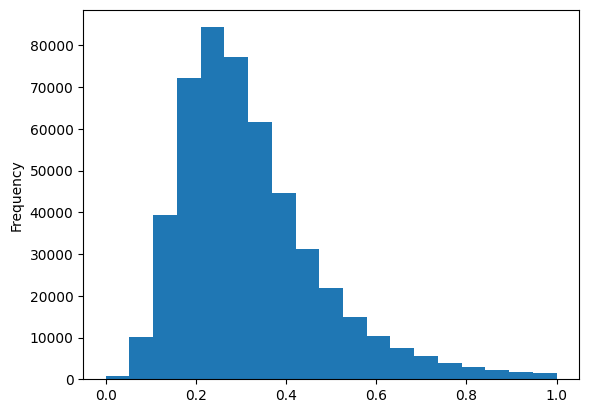

In [79]:
# gdf_sjoin["dyn_ratio"].plot.hist(bins=[0.001, 0.01, 0.1, 1, 10])
gdf_sjoin["depth_ratio"].plot.hist(bins=np.linspace(0,1, 20))

In [81]:
# Update greennessx2 with GLOBATHY
gdf_sjoin.rename({"Continent_left": "Continent"}).drop(columns="Continent_right").to_file(
    greennessx2_pth
)